# Module 2: Epidemic Modeling Template

## Team Members:
*(Fill in)*

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



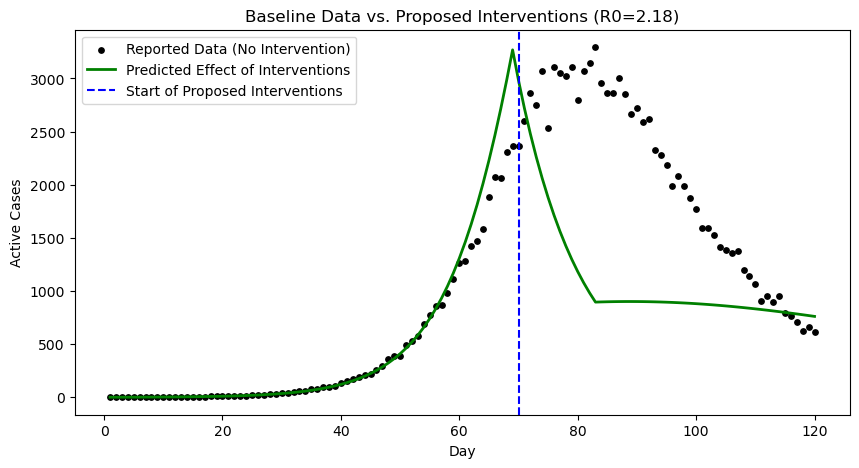

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Data
# -----------------------------
days_data = np.arange(1, 121)
reported_cases = [
    1,1,1,1,1,1,2,2,2,3,3,4,4,4,5,6,7,9,9,10,
    13,14,16,17,20,24,25,31,33,38,43,54,56,60,75,76,93,94,110,134,
    155,170,189,211,223,261,297,360,390,391,488,526,577,686,777,857,867,983,1116,1263,
    1284,1420,1469,1580,1883,2070,2061,2307,2364,2363,2602,2867,2754,3068,2538,3106,3047,3025,3109,2797,
    3070,3146,3294,2954,2867,2862,3006,2854,2663,2726,2590,2614,2323,2281,2187,1985,2084,1992,1880,1773,
    1590,1595,1524,1414,1388,1354,1376,1202,1142,1062,911,950,901,952,791,764,708,628,664,613
]

# -----------------------------
# 2. Parameters 
# -----------------------------
N = 40000
I0 = 1
gamma = 1/9 

# We fit to the data assuming THIS is the no-intervention path
early_days = days_data[:45]
ln_I = np.log(np.array(reported_cases[:45]))
slope, _ = np.polyfit(early_days, ln_I, 1)
beta_baseline = slope + gamma
R0_baseline = beta_baseline / gamma

# -----------------------------
# 3. Simulation Function
# -----------------------------
def simulate(apply_measures):
    S, I, R = np.zeros(120), np.zeros(120), np.zeros(120)
    S[0], I[0], R[0] = N-I0, I0, 0
    
    for t in range(1, 120):
        St, It, Rt = S[t-1], I[t-1], R[t-1]
        b = beta_baseline
        
        if apply_measures and t >= 69: # Day 70
            b *= 0.6 # Masks
            if 69 <= t < 83: b *= 0.2 # School closure (14 days)
            if t == 69:
                vax = min(St, 1800) # 2000 * 0.9
                St -= vax
                Rt += vax
                
        inf = b * St * It / N
        rec = gamma * It
        S[t], I[t], R[t] = St - inf, It + inf - rec, Rt + rec
    return I

# -----------------------------
# 4. Plotting
# -----------------------------
I_baseline = simulate(False)
I_intervention = simulate(True)

plt.figure(figsize=(10, 5))
plt.scatter(days_data, reported_cases, color='black', label='Reported Data (No Intervention)', s=15)
plt.plot(days_data, I_intervention, color='green', label='Predicted Effect of Interventions', linewidth=2)
plt.axvline(x=70, color='blue', linestyle='--', label='Start of Proposed Interventions')

plt.title(f"Baseline Data vs. Proposed Interventions (R0={R0_baseline:.2f})")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.legend()
plt.show()

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*